# <center> Multi-Channel Queuing Example
## <center> Systems Engineering and Analysis
## <center> <img src="https://www.engr.colostate.edu/~jdaily/Systems-EN-CSU-1-C357.svg" width="400" />
### <center> Prepared by: Dr. Jeremy Daily

---

In the single-channel example, an **event-driven** simulation gave faster and cleaner convergence than a tiny fixed time step.

We will do the same thing here for a **multi-channel queue**, also called an **M/M/c** queue:

- **M**: Poisson arrivals  
- **M**: Exponential service times  
- **c**: Multiple identical service channels  

This is a good model when there is **one waiting line** and the **next available channel** takes the next customer.

## A Colorado ski resort example

Imagine the base area of a Colorado ski resort with **three RFID pass-scanning gates** feeding a gondola line.

To keep the example simple:

- skier groups arrive randomly at an average rate of **2.4 groups per minute**
- each gate scans and sends a group forward at an average rate of **1.0 group per minute**
- there are **3 identical gates**
- if all gates are busy, groups wait in **one common line**

So our queueing parameters are:

- arrival rate: $\lambda = 2.4$ groups/minute
- service rate per gate: $\mu = 1.0$ group/minute
- number of channels: $c = 3$

Because $\lambda < c\mu$, the queue is stable:

$$
2.4 < 3(1.0) = 3.0
$$

In [1]:
import heapq
import math
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.4f}".format

ModuleNotFoundError: No module named 'pandas'

In [2]:
# Ski resort queue parameters
lam = 2.4   # arrival rate: groups per minute
mu = 1.0    # service rate per gate: groups per minute
c = 3       # number of gates

rho = lam / (c * mu)
rho

0.7999999999999999

## M/M/c formulas

For the M/M/c model, the standard steady-state formulas are based on:

- offered load: $a = \lambda / \mu$
- utilization per channel: $\rho = \lambda / (c\mu)$

The probability that the system is empty is

$$
P_0 =
\left[
\sum_{n=0}^{c-1} \frac{a^n}{n!}
+
\frac{a^c}{c!}\frac{1}{1-\rho}
\right]^{-1}
$$

From that, we can compute:

- probability an arrival must wait: $P(\text{wait})$
- average queue length: $L_q$
- average number in system: $L$
- average waiting time in queue: $W_q$
- average time in system: $W$

In [3]:
def mmc_theory(lam, mu, c):
    """Steady-state formulas for an M/M/c queue (Erlang C model)."""
    if lam <= 0 or mu <= 0:
        raise ValueError("Rates must be positive.")
    if int(c) != c or c < 1:
        raise ValueError("c must be a positive integer.")

    c = int(c)
    rho = lam / (c * mu)

    if rho >= 1:
        raise ValueError("The M/M/c queue is stable only when lambda < c * mu.")

    a = lam / mu

    series = sum((a**n) / math.factorial(n) for n in range(c))
    tail = (a**c) / math.factorial(c) * (1 / (1 - rho))
    P0 = 1 / (series + tail)

    P_wait = P0 * (a**c) / (math.factorial(c) * (1 - rho))
    Lq = P0 * (a**c) * rho / (math.factorial(c) * (1 - rho)**2)
    Wq = Lq / lam
    W = Wq + 1 / mu
    L = lam * W

    return {
        "rho": rho,
        "P0": P0,
        "P_wait": P_wait,
        "Lq": Lq,
        "L": L,
        "Wq": Wq,
        "W": W,
    }

theory = mmc_theory(lam, mu, c)

theory_table = pd.DataFrame(
    {
        "Metric": ["rho", "P0", "P(wait)", "Lq", "L", "Wq (min)", "W (min)"],
        "Theory": [
            theory["rho"],
            theory["P0"],
            theory["P_wait"],
            theory["Lq"],
            theory["L"],
            theory["Wq"],
            theory["W"],
        ],
    }
)

theory_table

,Metric,Theory
0,rho,0.8000
1,P0,0.0562
2,P(wait),0.6472
3,Lq,2.5888
4,L,4.9888
5,Wq (min),1.0787
6,W (min),2.0787


## Event-driven simulation

Instead of moving time forward in tiny steps, we jump directly to the **next event**:

- the next arrival, or
- the next service completion

That is both **faster** and **more accurate** for an M/M/c queue.

To reduce start-up bias, we will ignore an initial **warm-up** period before collecting statistics.

In [4]:
def simulate_mmc(
    lam,
    mu,
    c,
    total_departures=400_000,
    warmup_departures=40_000,
    seed=7,
    record_every=20_000,
):
    """Event-driven simulation of an M/M/c queue with a single common line."""
    if lam <= 0 or mu <= 0:
        raise ValueError("Rates must be positive.")
    if int(c) != c or c < 1:
        raise ValueError("c must be a positive integer.")

    c = int(c)

    if lam >= c * mu:
        raise ValueError("The M/M/c queue is unstable unless lambda < c * mu.")
    if total_departures <= 0 or warmup_departures < 0:
        raise ValueError("Use total_departures > 0 and warmup_departures >= 0.")

    rng = np.random.default_rng(seed)

    time_now = 0.0
    next_arrival = rng.exponential(1 / lam)

    # service_heap holds the busy channels as:
    # (departure_time, arrival_time, service_start_time)
    service_heap = []
    queue = deque()

    departures = 0
    collecting = False
    start_collect_time = None

    area_n = 0.0
    area_q = 0.0
    wait_sum = 0.0
    system_sum = 0.0
    wait_count = 0
    kept_departures = 0

    history_rows = []
    next_record = record_every if record_every else None

    while departures < total_departures + warmup_departures:
        next_departure = service_heap[0][0] if service_heap else np.inf

        # Decide which event happens next
        if next_arrival <= next_departure:
            event_time = next_arrival
            arrival_event = True
        else:
            event_time = next_departure
            arrival_event = False

        # Time-average statistics
        if collecting:
            dt = event_time - time_now
            area_n += (len(service_heap) + len(queue)) * dt
            area_q += len(queue) * dt

        time_now = event_time

        if arrival_event:
            arrival_time = time_now

            if len(service_heap) < c:
                # Start service immediately
                service_start = time_now
                departure_time = time_now + rng.exponential(1 / mu)
                heapq.heappush(service_heap, (departure_time, arrival_time, service_start))
            else:
                # Join the common waiting line
                queue.append(arrival_time)

            next_arrival = time_now + rng.exponential(1 / lam)

        else:
            # One service finishes
            departure_time, arrival_time, service_start = heapq.heappop(service_heap)
            departures += 1

            if collecting:
                kept_departures += 1
                wait = service_start - arrival_time
                system_time = time_now - arrival_time

                wait_sum += wait
                system_sum += system_time
                wait_count += wait > 0

            # If someone is waiting, start service right away
            if queue:
                queued_arrival = queue.popleft()
                next_service_start = time_now
                next_finish = time_now + rng.exponential(1 / mu)
                heapq.heappush(service_heap, (next_finish, queued_arrival, next_service_start))

            # Start collecting only after the warm-up departures are complete
            if (not collecting) and departures >= warmup_departures:
                collecting = True
                start_collect_time = time_now

                area_n = 0.0
                area_q = 0.0
                wait_sum = 0.0
                system_sum = 0.0
                wait_count = 0
                kept_departures = 0

                history_rows = []
                next_record = record_every if record_every else None

            # Save running estimates to visualize convergence
            if collecting and next_record is not None and kept_departures >= next_record:
                elapsed = time_now - start_collect_time
                history_rows.append(
                    {
                        "Departures": kept_departures,
                        "L": area_n / elapsed,
                        "Lq": area_q / elapsed,
                        "W": system_sum / kept_departures,
                        "Wq": wait_sum / kept_departures,
                        "P_wait": wait_count / kept_departures,
                    }
                )
                next_record += record_every

    elapsed = time_now - start_collect_time

    return {
        "rho": lam / (c * mu),
        "L": area_n / elapsed,
        "Lq": area_q / elapsed,
        "W": system_sum / kept_departures,
        "Wq": wait_sum / kept_departures,
        "P_wait": wait_count / kept_departures,
        "departures_used": kept_departures,
        "elapsed_time": elapsed,
        "history": pd.DataFrame(history_rows),
    }

In [5]:
sim = simulate_mmc(
    lam=lam,
    mu=mu,
    c=c,
    total_departures=400_000,
    warmup_departures=40_000,
    seed=7,
    record_every=20_000,
)

sim

{'rho': 0.7999999999999999,
 'L': 4.98783718836836,
 'Lq': 2.5862704837242703,
 'W': 2.076305918250768,
 'Wq': 1.0766023362902275,
 'P_wait': 0.64793,
 'departures_used': 400000,
 'elapsed_time': 166507.75356774055,
 'history':     Departures      L     Lq      W     Wq  P_wait
 0        20000 4.8410 2.4477 2.0113 1.0171  0.6423
 1        40000 5.0263 2.6319 2.0931 1.0961  0.6447
 2        60000 4.9343 2.5414 2.0589 1.0605  0.6413
 3        80000 4.9389 2.5416 2.0572 1.0587  0.6434
 4       100000 5.0315 2.6233 2.0908 1.0901  0.6487
 5       120000 4.9877 2.5827 2.0735 1.0737  0.6480
 6       140000 4.9874 2.5824 2.0721 1.0729  0.6476
 7       160000 4.9869 2.5817 2.0731 1.0732  0.6476
 8       180000 4.9856 2.5829 2.0744 1.0747  0.6465
 9       200000 4.9695 2.5683 2.0676 1.0686  0.6457
 10      220000 5.0054 2.6018 2.0816 1.0820  0.6473
 11      240000 4.9977 2.5960 2.0794 1.0801  0.6473
 12      260000 5.0042 2.6030 2.0825 1.0832  0.6474
 13      280000 5.0063 2.6053 2.0830 1.0840  

In [6]:
comparison = pd.DataFrame(
    {
        "Metric": ["rho", "P(wait)", "Lq", "L", "Wq (min)", "W (min)"],
        "Theory": [
            theory["rho"],
            theory["P_wait"],
            theory["Lq"],
            theory["L"],
            theory["Wq"],
            theory["W"],
        ],
        "Simulation": [
            sim["rho"],
            sim["P_wait"],
            sim["Lq"],
            sim["L"],
            sim["Wq"],
            sim["W"],
        ],
    }
)

comparison["Absolute Error"] = (comparison["Simulation"] - comparison["Theory"]).abs()

comparison

,Metric,Theory,Simulation,Absolute Error
0,rho,0.8000,0.8000,0.0000
1,P(wait),0.6472,0.6479,0.0007
2,Lq,2.5888,2.5863,0.0025
3,L,4.9888,4.9878,0.0009
4,Wq (min),1.0787,1.0766,0.0020
5,W (min),2.0787,2.0763,0.0023


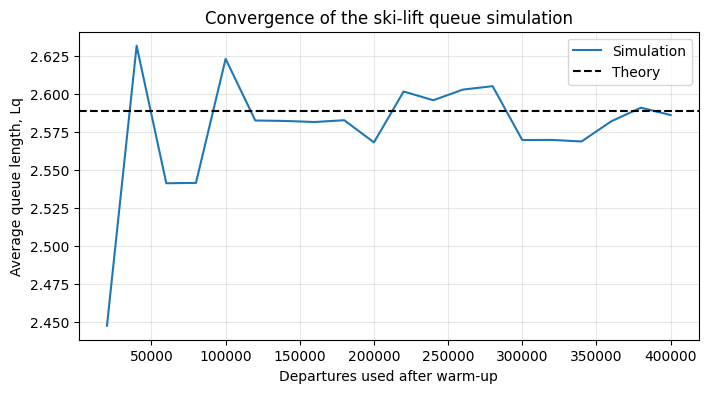

In [7]:
history = sim["history"]

plt.figure(figsize=(8, 4))
plt.plot(history["Departures"], history["Lq"], label="Simulation")
plt.axhline(theory["Lq"], linestyle="--", color="black", label="Theory")
plt.xlabel("Departures used after warm-up")
plt.ylabel("Average queue length, Lq")
plt.title("Convergence of the ski-lift queue simulation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## A quick interpretation

For this ski resort example, the three scanning gates are busy about **80%** of the time:

$$
\rho = \frac{\lambda}{c\mu} = 0.8
$$

That is a healthy but busy system:

- the queue is stable
- many arrivals still have to wait
- the average waiting time is around **1.08 minutes**
- the average total time in the system is around **2.08 minutes**

Because the simulation is event-driven and we use a warm-up period, the estimates converge much faster than a tiny fixed time step model.

You can now experiment by changing:

- `c` to test more or fewer gates
- `lam` to model busier or quieter arrival conditions
- `mu` to model faster or slower service

In [8]:
# Optional: compare a few staffing choices for the ski resort

choices = []
for gates in [2, 3, 4, 5]:
    capacity = gates * mu

    if lam >= capacity:
        choices.append(
            {
                "gates": gates,
                "rho": lam / capacity,
                "P(wait)": np.nan,
                "Lq": np.nan,
                "Wq (min)": np.nan,
                "W (min)": np.nan,
                "note": "unstable because lambda >= c * mu",
            }
        )
    else:
        row = mmc_theory(lam=lam, mu=mu, c=gates)
        choices.append(
            {
                "gates": gates,
                "rho": row["rho"],
                "P(wait)": row["P_wait"],
                "Lq": row["Lq"],
                "Wq (min)": row["Wq"],
                "W (min)": row["W"],
                "note": "stable",
            }
        )

pd.DataFrame(choices)

,gates,rho,P(wait),Lq,Wq (min),W (min),note
0,2,1.2000,NaN,NaN,NaN,NaN,unstable because lambda >= c * mu
1,3,0.8000,0.6472,2.5888,1.0787,2.0787,stable
2,4,0.6000,0.2870,0.4306,0.1794,1.1794,stable
3,5,0.4800,0.1135,0.1048,0.0437,1.0437,stable
